## Gradient checker

In [1]:
from __future__ import annotations  # lazy annotations: allows tuple[...] / X | None on older kernels

from typing import Callable
import numpy as np

In [2]:
def numeric_gradient(
    scalar_function: Callable[[np.ndarray], float],
    feature_values: np.ndarray,
    h: float = 1e-5
) -> np.ndarray:
    gradient = np.zeros_like(feature_values, dtype=float)

    for i in range(feature_values.size):
        mask = np.zeros_like(feature_values, dtype=float)
        mask.flat[i] = h
        gradient.flat[i] = (scalar_function(feature_values + mask) - scalar_function(feature_values - mask)) / (2 * h)
    return gradient

def stable_softmax(x: np.ndarray) -> np.ndarray:
    e = np.exp(x - np.max(x))
    return e / np.sum(e)

## Linear

In [3]:
class Linear:
    """Fully-connected layer:  Y = X @ W + b

    Shapes:
        X : (batch, n_in)     activations from the previous layer
        W : (n_in, n_out)
        b : (n_out,)
        Y : (batch, n_out)
    """

    def __init__(self, n_in: int, n_out: int, seed: int = 0) -> None:
        rng = np.random.default_rng(seed)
        
        # Xavier-style init: variance 1/n_in, i.e. scale by 1/sqrt(n_in).
        #   Each output sums n_in products, so unscaled standard-normal weights make
        #   activations grow by ~sqrt(n_in) per layer. In a deep stack that saturates
        #   softmax and stalls learning (CharGPT with unscaled init starts at loss
        #   ~14.8 instead of ln(vocab) ~3.4 and never recovers). Bias starts at zero.
        self.W: np.ndarray = rng.standard_normal((n_in, n_out)) / np.sqrt(n_in)
        self.b: np.ndarray = np.zeros(n_out)
            
        # caches / gradient buffers (filled during forward/backward)
        self.X: np.ndarray | None = None   # previous layer's activations, saved for backward
        self.d_w: np.ndarray | None = None
        self.d_b: np.ndarray | None = None

    def forward(self, X: np.ndarray) -> np.ndarray:
        """X: (batch, n_in) -> Y: (batch, n_out)."""
        self.X = X                     # cache X: backward needs it to compute d_w
        return X @ self.W + self.b     # b (n_out,) broadcasts across every row

    def backward(self, d_y: np.ndarray) -> np.ndarray:
        """d_y: (batch, n_out) upstream gradient ∂L/∂Y. Returns d_x: (batch, n_in)."""
        
        # d_w: chain rule + sum over the batch -> X.T @ d_y.
        #   local derivative ∂Y/∂W is X; a weight is reused across all samples,
        #   so the matmul sums those per-sample contributions. Shape (n_in, n_out).
        self.d_w = self.X.T @ d_y

        # d_b: local derivative ∂Y/∂b is 1, so just sum d_y over the batch axis.
        #   Shape (n_out,) -- one gradient per bias.
        self.d_b = d_y.sum(axis=0)

        # d_x: gradient to hand back to the previous layer (becomes its d_y).
        #   local derivative ∂Y/∂X is W, so d_x = d_y @ W.T. Shape (batch, n_in).
        d_x = d_y @ self.W.T
        
        return d_x

    def parameters(self) -> list[tuple[np.ndarray, np.ndarray]]:
        """(value, gradient) pairs for the optimizer: [(W, d_w), (b, d_b)].

        The optimizer reads this each step: values are mutated in place, gradients
        are re-fetched (backward rebinds d_w/d_b to new arrays every call).
        """
        return [(self.W, self.d_w), (self.b, self.d_b)]

    def zero_grad(self) -> None:
        """Reset gradient buffers (called after each optimizer step)."""
        self.d_w = None
        self.d_b = None

## Cross-entropy loss

In [4]:
def cross_entropy(
    raw_class_scores: np.ndarray,
    correct_class_indices: np.ndarray,
) -> tuple[float, np.ndarray]:
    """Softmax cross-entropy for a batch of classification examples.

    Args:
        raw_class_scores      : (number_of_examples_in_batch, number_of_classes)
                              raw scores (logits), one row per example
        correct_class_indices : (number_of_examples_in_batch,)
                              correct class index for each example

    Returns:
        mean_loss          : float        mean cross-entropy over the batch
        gradient_wrt_scores : np.ndarray   (number_of_examples_in_batch, number_of_classes)
                            ∂L/∂scores = (softmax - onehot) / number_of_examples_in_batch
    """
    number_of_examples_in_batch: int = raw_class_scores.shape[0]
    example_rows: np.ndarray = np.arange(number_of_examples_in_batch)   # [0, 1, ..., batch-1], to index each row

    # --- stable softmax, per row (subtract each row's max -> no overflow) ---
    stabilized_scores: np.ndarray = raw_class_scores - raw_class_scores.max(axis=1, keepdims=True)
    exponentiated_scores: np.ndarray = np.exp(stabilized_scores)
    class_probabilities: np.ndarray = exponentiated_scores / exponentiated_scores.sum(axis=1, keepdims=True)

    # --- loss: -log(prob of the correct class), averaged over the batch ---
    probability_of_correct_class: np.ndarray = class_probabilities[example_rows, correct_class_indices]
    negative_log_prob_of_correct_class: np.ndarray = -np.log(probability_of_correct_class)   # (batch,)
    mean_loss: float = float(negative_log_prob_of_correct_class.mean())

    # --- gradient: the clean combined form  softmax - onehot  ---
    #   start from probabilities, subtract 1 at each row's correct class, average over batch
    gradient_wrt_scores: np.ndarray = class_probabilities.copy()
    gradient_wrt_scores[example_rows, correct_class_indices] -= 1
    gradient_wrt_scores /= number_of_examples_in_batch

    return mean_loss, gradient_wrt_scores

## Adam optimizer

In [5]:
class Adam:
    """Adam optimizer: updates every parameter of the given layers in place.

    Holds per-parameter state (first/second moment estimates) and shared state
    (timestep, learning rate, betas, epsilon). Each parameter's update is fully
    independent -- the optimizer just loops over all of them.

    Design:
        - references the layers, so it can reach every parameter
        - reads gradients FRESH each step via layer.parameters()
          (backward rebinds d_w/d_b to new arrays every call)
        - updates values IN PLACE (value -= ...), so the layer's W / b actually change
    """

    def __init__(
        self,
        layers: list,
        lr: float = 1e-3,
        beta1: float = 0.9,
        beta2: float = 0.999,
        eps: float = 1e-8,
    ) -> None:
        self.layers: list = layers
        self.lr: float = lr
        self.beta1: float = beta1
        self.beta2: float = beta2
        self.eps: float = eps
        self.time_step: int = 0

        # one moment buffer per parameter, in the stable order parameters() yields.
        # sized from the VALUES (grads may still be None before the first backward).
        self.first_moment_estimates: list[np.ndarray] = []
        self.second_moment_estimates: list[np.ndarray] = []
        for layer in self.layers:
            for (parameter_value, _parameter_gradient) in layer.parameters():
                self.first_moment_estimates.append(np.zeros_like(parameter_value))
                self.second_moment_estimates.append(np.zeros_like(parameter_value))

    def step(self) -> None:
        """Apply one Adam update to every parameter, using the current gradients."""
        self.time_step += 1
        bias_correction_first: float = 1.0 - self.beta1 ** self.time_step
        bias_correction_second: float = 1.0 - self.beta2 ** self.time_step

        parameter_index: int = 0
        for layer in self.layers:
            for (parameter_value, parameter_gradient) in layer.parameters():   # fresh grads
                first_moment: np.ndarray = self.first_moment_estimates[parameter_index]
                second_moment: np.ndarray = self.second_moment_estimates[parameter_index]

                # update biased moment estimates (in place, so buffer identity is kept)
                first_moment *= self.beta1
                first_moment += (1.0 - self.beta1) * parameter_gradient
                second_moment *= self.beta2
                second_moment += (1.0 - self.beta2) * (parameter_gradient ** 2)

                # bias-corrected estimates (early steps would otherwise be too small)
                corrected_first_moment: np.ndarray = first_moment / bias_correction_first
                corrected_second_moment: np.ndarray = second_moment / bias_correction_second

                # in-place parameter update -> mutates the layer's W / b
                parameter_value -= self.lr * corrected_first_moment / (np.sqrt(corrected_second_moment) + self.eps)

                parameter_index += 1

    def zero_grad(self) -> None:
        """Reset every layer's gradient buffers after a step."""
        for layer in self.layers:
            layer.zero_grad()

## CharTokenizer

In [6]:
class CharTokenizer:
    """Character-level tokenizer: text <-> list of integer token ids.

    Vocabulary = special tokens + every unique character in the training text.
    Not a Layer: no parameters, never seen by the optimizer.
    """

    PAD_TOKEN: str = "<pad>"
    BOS_TOKEN: str = "<bos>"   # beginning of sequence
    EOS_TOKEN: str = "<eos>"   # end of sequence

    def __init__(self, training_text: str) -> None:
        special_tokens: list[str] = [self.PAD_TOKEN, self.BOS_TOKEN, self.EOS_TOKEN]
        unique_characters: list[str] = sorted(set(training_text))
        # id -> token (list index is the id); token -> id (inverse map)
        self.id_to_token: list[str] = special_tokens + unique_characters
        self.token_to_id: dict[str, int] = {token: token_id for token_id, token in enumerate(self.id_to_token)}

    @property
    def vocab_size(self) -> int:
        return len(self.id_to_token)

    @property
    def pad_id(self) -> int:
        return self.token_to_id[self.PAD_TOKEN]

    @property
    def bos_id(self) -> int:
        return self.token_to_id[self.BOS_TOKEN]

    @property
    def eos_id(self) -> int:
        return self.token_to_id[self.EOS_TOKEN]

    def encode(self, text: str, add_specials: bool = True) -> list[int]:
        """text -> token ids. If add_specials, wrap as <bos> ... <eos>."""
        token_ids: list[int] = [self.token_to_id[character] for character in text]
        if add_specials:
            token_ids = [self.bos_id] + token_ids + [self.eos_id]
        return token_ids

    def decode(self, token_ids: list[int], skip_specials: bool = True) -> str:
        """token ids -> text. If skip_specials, drop <pad>/<bos>/<eos>."""
        special_token_ids: set[int] = {self.pad_id, self.bos_id, self.eos_id}
        return "".join(
            self.id_to_token[token_id]
            for token_id in token_ids
            if not (skip_specials and token_id in special_token_ids)
        )

## Embedding

In [7]:
class Embedding:
    """Embedding layer: maps integer token ids to learned vectors (a row lookup).

    One trainable parameter: table (vocab_size, embedding_dim), one row per token.
        forward(ids)  -> table[ids]   (rows selected; caches ids)
        backward(d_out) -> None        (scatter-add into d_table; duplicate ids accumulate)

    Returns no input gradient — integer ids aren't differentiable, and Embedding is the
    first layer. Same parameters() contract as Linear, so the optimizer treats it the same.
    """

    def __init__(self, vocab_size: int, embedding_dim: int, seed: int = 0,
                 init_scale: float = 0.02) -> None:
        random_generator = np.random.default_rng(seed)
        # small init (GPT uses ~N(0, 0.02)): embeddings feed straight into the residual
        # stream, so large initial rows would dominate everything downstream.
        self.table: np.ndarray = (
            random_generator.standard_normal((vocab_size, embedding_dim)) * init_scale
        )
        # cache + gradient buffer (filled during forward/backward)
        self.token_ids: np.ndarray | None = None
        self.d_table: np.ndarray | None = None

    def forward(self, token_ids: np.ndarray) -> np.ndarray:
        """token_ids: integer array of shape S -> embeddings of shape S + (embedding_dim,)."""
        self.token_ids = token_ids          # cache ids: backward needs to know which rows were used
        return self.table[token_ids]       # fancy indexing = row lookup

    def backward(self, d_out: np.ndarray) -> None:
        """d_out: ∂L/∂(looked-up rows), same shape as the forward output.

        Scatter-add each position's gradient into the row of its id. np.add.at accumulates
        on repeated ids (plain d_table[ids] = d_out would overwrite duplicates -> wrong).
        Returns None: there is no gradient to pass back to integer ids.
        """
        self.d_table = np.zeros_like(self.table)
        np.add.at(self.d_table, self.token_ids, d_out)
        return None

    def parameters(self) -> list[tuple[np.ndarray, np.ndarray]]:
        """(value, gradient) pairs for the optimizer: [(table, d_table)]."""
        return [(self.table, self.d_table)]

    def zero_grad(self) -> None:
        """Reset the gradient buffer (called after each optimizer step)."""
        self.d_table = None

## CausalSelfAttention

In [8]:
def softmax_rows(scores: np.ndarray) -> np.ndarray:
    """Row-wise stable softmax: every ROW becomes its own distribution summing to 1.

    stable_softmax normalises over the whole array; attention needs one distribution per
    query row, so max/sum are taken along the last axis only. Rows may contain -inf
    (masked positions): exp(-inf) = 0, so those receive exactly zero probability.
    """
    shifted: np.ndarray = scores - scores.max(axis=-1, keepdims=True)
    exponentiated: np.ndarray = np.exp(shifted)
    return exponentiated / exponentiated.sum(axis=-1, keepdims=True)


class CausalSelfAttention:
    """Single-head causal self-attention over ONE sequence.

        forward :  X     (T, d_model)  ->  output (T, d_head)
        backward:  d_out (T, d_head)   ->  d_x    (T, d_model)

    output = softmax(Q @ K.T / sqrt(d_head) + causal_mask) @ V

    Q, K and V are three Linear projections of the SAME X, so the gradient flowing back
    into X is the SUM of those three paths.
    """

    def __init__(self, d_model: int, d_head: int, seed: int = 0) -> None:
        self.d_model: int = d_model
        self.d_head: int = d_head
        # three independent projections of the same input (reuse our Linear layer)
        self.query_projection: Linear = Linear(d_model, d_head, seed=seed)
        self.key_projection: Linear = Linear(d_model, d_head, seed=seed + 1)
        self.value_projection: Linear = Linear(d_model, d_head, seed=seed + 2)
        # caches filled by forward, consumed by backward
        self.Q: np.ndarray | None = None
        self.K: np.ndarray | None = None
        self.V: np.ndarray | None = None
        self.attention_weights: np.ndarray | None = None

    def forward(self, X: np.ndarray) -> np.ndarray:
        """X: (T, d_model) -> output: (T, d_head)."""
        sequence_length: int = X.shape[0]

        self.Q = self.query_projection.forward(X)   # (T, d_head)  "what am I looking for?"
        self.K = self.key_projection.forward(X)     # (T, d_head)  "what do I offer?"
        self.V = self.value_projection.forward(X)   # (T, d_head)  "what do I pass on?"

        # every query against every key; /sqrt(d_head) keeps softmax out of saturation
        raw_scores: np.ndarray = (self.Q @ self.K.T) / np.sqrt(self.d_head)

        # causal mask: position i may only attend to positions j <= i (lower triangle)
        allowed_positions: np.ndarray = np.tril(
            np.ones((sequence_length, sequence_length), dtype=bool)
        )
        masked_scores: np.ndarray = np.where(allowed_positions, raw_scores, -np.inf)

        self.attention_weights = softmax_rows(masked_scores)   # (T, T), rows sum to 1
        return self.attention_weights @ self.V                 # (T, d_head)

    def backward(self, d_out: np.ndarray) -> np.ndarray:
        """d_out: ∂L/∂output (T, d_head). Returns d_x: ∂L/∂X (T, d_model)."""

        # 1. through the weighted sum  output = attention_weights @ V
        d_attention_weights: np.ndarray = d_out @ self.V.T          # (T, T)
        d_v: np.ndarray = self.attention_weights.T @ d_out          # (T, d_head)

        # 2. through the row-wise softmax:  ∂L/∂s = p * (∂L/∂p - Σ(∂L/∂p * p))
        #    masked entries have p = 0, so their gradient stays 0 -> no leak to the future.
        row_weighted_sum: np.ndarray = (
            d_attention_weights * self.attention_weights
        ).sum(axis=-1, keepdims=True)
        d_masked_scores: np.ndarray = self.attention_weights * (
            d_attention_weights - row_weighted_sum
        )

        # 3. through the 1/sqrt(d_head) scaling
        d_raw_scores: np.ndarray = d_masked_scores / np.sqrt(self.d_head)

        # 4. through raw_scores = Q @ K.T
        d_q: np.ndarray = d_raw_scores @ self.K                     # (T, d_head)
        d_k: np.ndarray = d_raw_scores.T @ self.Q                   # (T, d_head)

        # 5. through the three projections; X fed all three, so the paths ADD
        d_x: np.ndarray = (
            self.query_projection.backward(d_q)
            + self.key_projection.backward(d_k)
            + self.value_projection.backward(d_v)
        )
        return d_x

    def parameters(self) -> list[tuple[np.ndarray, np.ndarray]]:
        return (
            self.query_projection.parameters()
            + self.key_projection.parameters()
            + self.value_projection.parameters()
        )

    def zero_grad(self) -> None:
        self.query_projection.zero_grad()
        self.key_projection.zero_grad()
        self.value_projection.zero_grad()

## MultiHeadAttention

In [9]:
class MultiHeadAttention:
    """Several CausalSelfAttention heads in parallel, concatenated and projected.

        forward :  X     (T, d_model) -> output (T, d_model)
        backward:  d_out (T, d_model) -> d_x    (T, d_model)

    Every head sees the same X, so backward SUMS each head's d_x.
    """

    def __init__(self, d_model: int, number_of_heads: int, seed: int = 0) -> None:
        if d_model % number_of_heads != 0:
            raise ValueError(
                f"d_model ({d_model}) must be divisible by number_of_heads ({number_of_heads})"
            )
        self.d_model: int = d_model
        self.number_of_heads: int = number_of_heads
        self.d_head: int = d_model // number_of_heads

        # distinct seeds so heads start differently and can specialise
        self.heads: list[CausalSelfAttention] = [
            CausalSelfAttention(d_model, self.d_head, seed=seed + 10 * head_index)
            for head_index in range(number_of_heads)
        ]
        # mixes the concatenated head outputs back into model width
        self.output_projection: Linear = Linear(d_model, d_model, seed=seed + 7)

    def forward(self, X: np.ndarray) -> np.ndarray:
        """X: (T, d_model) -> output: (T, d_model)."""
        head_outputs: list[np.ndarray] = [head.forward(X) for head in self.heads]
        concatenated_heads: np.ndarray = np.concatenate(head_outputs, axis=-1)  # (T, d_model)
        return self.output_projection.forward(concatenated_heads)

    def backward(self, d_out: np.ndarray) -> np.ndarray:
        """d_out: ∂L/∂output (T, d_model). Returns d_x: ∂L/∂X (T, d_model)."""
        # back through the mixing projection, then split the gradient per head
        d_concatenated: np.ndarray = self.output_projection.backward(d_out)
        per_head_gradients: list[np.ndarray] = np.split(
            d_concatenated, self.number_of_heads, axis=-1
        )

        # every head read the same X -> accumulate their input gradients
        d_x: np.ndarray = np.zeros_like(d_concatenated)
        for head, head_gradient in zip(self.heads, per_head_gradients):
            d_x += head.backward(head_gradient)
        return d_x

    def parameters(self) -> list[tuple[np.ndarray, np.ndarray]]:
        collected: list[tuple[np.ndarray, np.ndarray]] = []
        for head in self.heads:
            collected += head.parameters()
        return collected + self.output_projection.parameters()

    def zero_grad(self) -> None:
        for head in self.heads:
            head.zero_grad()
        self.output_projection.zero_grad()

## LayerNorm

In [10]:
class LayerNorm:
    """Normalizes each token across its FEATURE dimension, then scales and shifts.

        forward :  X     (..., d_model) -> Y   (..., d_model)
        backward:  d_y   (..., d_model) -> d_x (..., d_model)

    y = gamma * (x - mean) / sqrt(variance + eps) + beta,  with mean/variance taken
    over the last axis (one token), NOT over the batch.

    Two trainable parameters, both of shape (d_model,):
        gamma - per-feature scale (init 1 -> starts as a pure normalizer)
        beta  - per-feature shift (init 0)
    """

    def __init__(self, d_model: int, eps: float = 1e-5) -> None:
        self.d_model: int = d_model
        self.eps: float = eps
        # identity transform at init: scale 1, shift 0
        self.gamma: np.ndarray = np.ones(d_model)
        self.beta: np.ndarray = np.zeros(d_model)
        # caches + gradient buffers
        self.normalized_input: np.ndarray | None = None      # x_hat, needed by backward
        self.standard_deviation: np.ndarray | None = None    # sqrt(variance + eps)
        self.d_gamma: np.ndarray | None = None
        self.d_beta: np.ndarray | None = None

    def forward(self, X: np.ndarray) -> np.ndarray:
        """X: (..., d_model) -> Y: (..., d_model). Normalizes over the LAST axis."""
        feature_mean: np.ndarray = X.mean(axis=-1, keepdims=True)
        feature_variance: np.ndarray = X.var(axis=-1, keepdims=True)   # biased (1/d), as in the paper

        self.standard_deviation = np.sqrt(feature_variance + self.eps)
        self.normalized_input = (X - feature_mean) / self.standard_deviation

        return self.gamma * self.normalized_input + self.beta

    def backward(self, d_y: np.ndarray) -> np.ndarray:
        """d_y: ∂L/∂Y (..., d_model). Returns d_x: ∂L/∂X (..., d_model)."""
        # every axis except the feature axis is summed over: gamma/beta are shared
        # across all tokens, so each receives every token's contribution.
        summed_axes: tuple[int, ...] = tuple(range(d_y.ndim - 1))
        self.d_gamma = (d_y * self.normalized_input).sum(axis=summed_axes)
        self.d_beta = d_y.sum(axis=summed_axes)

        # gradient w.r.t. the normalized values
        d_normalized: np.ndarray = d_y * self.gamma

        # Three terms: the direct path, minus the mean correction, minus the variance
        # correction. They appear because mu and sigma depend on EVERY feature of the
        # token, so perturbing one feature moves all outputs of that token.
        mean_of_d_normalized: np.ndarray = d_normalized.mean(axis=-1, keepdims=True)
        mean_of_d_normalized_times_x_hat: np.ndarray = (
            d_normalized * self.normalized_input
        ).mean(axis=-1, keepdims=True)

        d_x: np.ndarray = (
            d_normalized
            - mean_of_d_normalized
            - self.normalized_input * mean_of_d_normalized_times_x_hat
        ) / self.standard_deviation
        return d_x

    def parameters(self) -> list[tuple[np.ndarray, np.ndarray]]:
        """(value, gradient) pairs for the optimizer: [(gamma, d_gamma), (beta, d_beta)]."""
        return [(self.gamma, self.d_gamma), (self.beta, self.d_beta)]

    def zero_grad(self) -> None:
        self.d_gamma = None
        self.d_beta = None

## Gelu and FeedForward

In [11]:
class Gelu:
    """GELU activation (tanh approximation), elementwise. No parameters.

        gelu(x) = 0.5 * x * (1 + tanh( sqrt(2/pi) * (x + 0.044715 * x^3) ))

    Included as a Layer-shaped class (forward/backward/parameters) so the blocks can
    chain it like any other layer; parameters() is simply empty.
    """

    INNER_COEFFICIENT: float = 0.044715

    def __init__(self) -> None:
        self.X: np.ndarray | None = None   # cached input, needed by backward

    def _inner(self, X: np.ndarray) -> np.ndarray:
        """The argument of tanh: sqrt(2/pi) * (x + 0.044715 x^3)."""
        return np.sqrt(2.0 / np.pi) * (X + self.INNER_COEFFICIENT * X ** 3)

    def forward(self, X: np.ndarray) -> np.ndarray:
        self.X = X
        return 0.5 * X * (1.0 + np.tanh(self._inner(X)))

    def backward(self, d_y: np.ndarray) -> np.ndarray:
        """Elementwise chain rule: d_x = d_y * gelu'(x).

        gelu'(x) = 0.5*(1 + tanh(u)) + 0.5*x*(1 - tanh(u)^2) * du/dx
        with u = sqrt(2/pi)*(x + c x^3)  and  du/dx = sqrt(2/pi)*(1 + 3c x^2).
        """
        X: np.ndarray = self.X
        tanh_of_inner: np.ndarray = np.tanh(self._inner(X))
        d_inner_d_x: np.ndarray = np.sqrt(2.0 / np.pi) * (
            1.0 + 3.0 * self.INNER_COEFFICIENT * X ** 2
        )
        gelu_derivative: np.ndarray = 0.5 * (1.0 + tanh_of_inner) + 0.5 * X * (
            1.0 - tanh_of_inner ** 2
        ) * d_inner_d_x
        return d_y * gelu_derivative

    def parameters(self) -> list[tuple[np.ndarray, np.ndarray]]:
        return []          # no trainable parameters

    def zero_grad(self) -> None:
        return None


class FeedForward:
    """Position-wise MLP sub-layer:  Linear(d -> 4d) -> GELU -> Linear(4d -> d).

        forward :  X     (T, d_model) -> Y   (T, d_model)
        backward:  d_y   (T, d_model) -> d_x (T, d_model)

    Applied to every token independently -- no mixing across positions happens here.
    """

    def __init__(self, d_model: int, expansion_factor: int = 4, seed: int = 0) -> None:
        self.d_model: int = d_model
        self.hidden_dim: int = expansion_factor * d_model
        self.input_projection: Linear = Linear(d_model, self.hidden_dim, seed=seed)
        self.activation: Gelu = Gelu()
        self.output_projection: Linear = Linear(self.hidden_dim, d_model, seed=seed + 1)

    def forward(self, X: np.ndarray) -> np.ndarray:
        expanded: np.ndarray = self.input_projection.forward(X)      # (T, 4*d_model)
        activated: np.ndarray = self.activation.forward(expanded)    # (T, 4*d_model)
        return self.output_projection.forward(activated)             # (T, d_model)

    def backward(self, d_y: np.ndarray) -> np.ndarray:
        d_activated: np.ndarray = self.output_projection.backward(d_y)
        d_expanded: np.ndarray = self.activation.backward(d_activated)
        return self.input_projection.backward(d_expanded)

    def parameters(self) -> list[tuple[np.ndarray, np.ndarray]]:
        return self.input_projection.parameters() + self.output_projection.parameters()

    def zero_grad(self) -> None:
        self.input_projection.zero_grad()
        self.output_projection.zero_grad()

## TransformerBlock

In [12]:
class TransformerBlock:
    """One pre-norm decoder block:

        h = X + attention(LayerNorm_1(X))
        Y = h + feed_forward(LayerNorm_2(h))

        forward :  X     (T, d_model) -> Y   (T, d_model)
        backward:  d_y   (T, d_model) -> d_x (T, d_model)

    Residual backward rule: the gradient arriving at an addition goes to BOTH branches,
    so each residual contributes d_out (skip path) + branch gradient.
    """

    def __init__(self, d_model: int, number_of_heads: int, expansion_factor: int = 4,
                 seed: int = 0) -> None:
        self.d_model: int = d_model
        self.attention_norm: LayerNorm = LayerNorm(d_model)
        self.attention: MultiHeadAttention = MultiHeadAttention(d_model, number_of_heads, seed=seed)
        self.feed_forward_norm: LayerNorm = LayerNorm(d_model)
        self.feed_forward: FeedForward = FeedForward(d_model, expansion_factor, seed=seed + 100)

    def forward(self, X: np.ndarray) -> np.ndarray:
        """X: (T, d_model) -> Y: (T, d_model)."""
        # sub-layer 1: normalize, attend, add back onto the residual stream
        normalized_for_attention: np.ndarray = self.attention_norm.forward(X)
        attention_output: np.ndarray = self.attention.forward(normalized_for_attention)
        after_attention: np.ndarray = X + attention_output

        # sub-layer 2: normalize, per-token MLP, add back again
        normalized_for_feed_forward: np.ndarray = self.feed_forward_norm.forward(after_attention)
        feed_forward_output: np.ndarray = self.feed_forward.forward(normalized_for_feed_forward)
        return after_attention + feed_forward_output

    def backward(self, d_y: np.ndarray) -> np.ndarray:
        """d_y: ∂L/∂Y (T, d_model). Returns d_x: ∂L/∂X (T, d_model)."""
        # --- sub-layer 2 (MLP) ---
        # Y = after_attention + feed_forward_output, so d_y reaches both branches.
        d_feed_forward_branch: np.ndarray = self.feed_forward.backward(d_y)
        d_after_attention: np.ndarray = d_y + self.feed_forward_norm.backward(d_feed_forward_branch)

        # --- sub-layer 1 (attention) ---
        d_attention_branch: np.ndarray = self.attention.backward(d_after_attention)
        d_x: np.ndarray = d_after_attention + self.attention_norm.backward(d_attention_branch)
        return d_x

    def parameters(self) -> list[tuple[np.ndarray, np.ndarray]]:
        return (
            self.attention_norm.parameters()
            + self.attention.parameters()
            + self.feed_forward_norm.parameters()
            + self.feed_forward.parameters()
        )

    def zero_grad(self) -> None:
        self.attention_norm.zero_grad()
        self.attention.zero_grad()
        self.feed_forward_norm.zero_grad()
        self.feed_forward.zero_grad()

## CharGPT

In [13]:
class CharGPT:
    """Decoder-only Transformer over one sequence of character ids.

        forward :  token_ids (T,)          -> logits (T, vocab_size)
        backward:  d_logits  (T, vocab)    -> None   (gradients land in the layers)

    Stack: (token_embedding + position_embedding) -> N blocks -> LayerNorm -> Linear.
    T must not exceed max_sequence_length (the size of the positional table).
    """

    def __init__(
        self,
        vocab_size: int,
        d_model: int = 64,
        number_of_heads: int = 4,
        number_of_blocks: int = 3,
        max_sequence_length: int = 64,
        expansion_factor: int = 4,
        seed: int = 0,
    ) -> None:
        self.vocab_size: int = vocab_size
        self.d_model: int = d_model
        self.max_sequence_length: int = max_sequence_length

        self.token_embedding: Embedding = Embedding(vocab_size, d_model, seed=seed)
        # positional table: one learned row per POSITION (not per token)
        self.position_embedding: Embedding = Embedding(max_sequence_length, d_model, seed=seed + 1)
        self.blocks: list[TransformerBlock] = [
            TransformerBlock(d_model, number_of_heads, expansion_factor, seed=seed + 20 * (i + 1))
            for i in range(number_of_blocks)
        ]
        self.final_norm: LayerNorm = LayerNorm(d_model)
        self.output_projection: Linear = Linear(d_model, vocab_size, seed=seed + 5)

    def forward(self, token_ids: np.ndarray) -> np.ndarray:
        """token_ids: (T,) integer ids -> logits: (T, vocab_size)."""
        sequence_length: int = len(token_ids)
        if sequence_length > self.max_sequence_length:
            raise ValueError(
                f"sequence length {sequence_length} exceeds max_sequence_length "
                f"{self.max_sequence_length}"
            )

        token_vectors: np.ndarray = self.token_embedding.forward(token_ids)
        position_ids: np.ndarray = np.arange(sequence_length)
        position_vectors: np.ndarray = self.position_embedding.forward(position_ids)

        # "what" + "where", summed into one representation per position
        hidden_states: np.ndarray = token_vectors + position_vectors

        for block in self.blocks:
            hidden_states = block.forward(hidden_states)

        hidden_states = self.final_norm.forward(hidden_states)
        return self.output_projection.forward(hidden_states)     # (T, vocab_size)

    def backward(self, gradient_wrt_logits: np.ndarray) -> None:
        """Backprop from the loss gradient down to both embedding tables."""
        d_hidden: np.ndarray = self.output_projection.backward(gradient_wrt_logits)
        d_hidden = self.final_norm.backward(d_hidden)

        for block in reversed(self.blocks):      # reverse order on the way back
            d_hidden = block.backward(d_hidden)

        # hidden = token_vectors + position_vectors, so BOTH tables receive this gradient
        self.token_embedding.backward(d_hidden)
        self.position_embedding.backward(d_hidden)
        return None

    def parameters(self) -> list[tuple[np.ndarray, np.ndarray]]:
        collected: list[tuple[np.ndarray, np.ndarray]] = (
            self.token_embedding.parameters() + self.position_embedding.parameters()
        )
        for block in self.blocks:
            collected += block.parameters()
        return collected + self.final_norm.parameters() + self.output_projection.parameters()

    def zero_grad(self) -> None:
        self.token_embedding.zero_grad()
        self.position_embedding.zero_grad()
        for block in self.blocks:
            block.zero_grad()
        self.final_norm.zero_grad()
        self.output_projection.zero_grad()

    def parameter_count(self) -> int:
        """Total number of trainable scalars (for the report's model-size section)."""
        return int(sum(value.size for value, _gradient in self.parameters()))

    def generate(
        self,
        tokenizer: CharTokenizer,
        max_new_tokens: int = 200,
        temperature: float = 1.0,
        seed: int = 0,
        prompt: str = "",
    ) -> str:
        """Autoregressive generation. Crops context to max_sequence_length each step."""
        random_generator = np.random.default_rng(seed)
        generated_ids: list[int] = [tokenizer.bos_id] + tokenizer.encode(
            prompt, add_specials=False
        )

        for _ in range(max_new_tokens):
            # the positional table has a fixed size -> only the last window is visible
            context_ids: np.ndarray = np.array(generated_ids[-self.max_sequence_length:])
            logits: np.ndarray = self.forward(context_ids)
            last_position_logits: np.ndarray = logits[-1]              # predict AFTER the last token
            probabilities: np.ndarray = stable_softmax(last_position_logits / temperature)
            probabilities = probabilities / probabilities.sum()        # guard against rounding
            next_token_id: int = int(random_generator.choice(self.vocab_size, p=probabilities))
            generated_ids.append(next_token_id)
            if next_token_id == tokenizer.eos_id:
                break

        return tokenizer.decode(generated_ids)

## Demonstration — correctness of the from-scratch pieces

In [14]:
random_generator = np.random.default_rng(0)

# 1. a hand-written backward pass matches numerical differentiation
X = random_generator.standard_normal((4, 8))
d_y = random_generator.standard_normal((4, 8))
layer_norm = LayerNorm(8)
layer_norm.forward(X)
analytic = layer_norm.backward(d_y)
numerical = numeric_gradient(
    lambda flat: np.sum(layer_norm.forward(flat.reshape(X.shape)) * d_y), X.copy()
)
print(f"LayerNorm backward vs numerical : max difference {np.abs(analytic - numerical).max():.2e}")

# 2. causal attention never reads the future
attention = CausalSelfAttention(d_model=8, d_head=4)
sequence = random_generator.standard_normal((5, 8))
output_before = attention.forward(sequence).copy()
sequence_changed = sequence.copy()
sequence_changed[-1] += 10.0                      # change ONLY the last token
output_after = attention.forward(sequence_changed)
print(f"earlier outputs changed by     : {np.abs(output_before[:-1] - output_after[:-1]).max():.2e}")

# 3. the assembled model produces one distribution per position
model = CharGPT(vocab_size=20, d_model=16, number_of_heads=2, number_of_blocks=2,
                max_sequence_length=8)
logits = model.forward(np.array([3, 7, 1, 4]))
print(f"CharGPT logits shape           : {logits.shape}  ({model.parameter_count():,} parameters)")

LayerNorm backward vs numerical : max difference 8.44e-11
earlier outputs changed by     : 0.00e+00
CharGPT logits shape           : (4, 20)  (7,380 parameters)


# Training on Tiny Shakespeare

In [15]:
import os
import urllib.request

DATA_PATH: str = "data/tinyshakespeare.txt"
DATA_URL: str = ("https://raw.githubusercontent.com/karpathy/char-rnn/"
                 "master/data/tinyshakespeare/input.txt")

# load locally if present, otherwise fetch once (stdlib only)
if not os.path.exists(DATA_PATH):
    os.makedirs(os.path.dirname(DATA_PATH), exist_ok=True)
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)

with open(DATA_PATH, encoding="utf-8") as corpus_file:
    shakespeare_text: str = corpus_file.read()

shakespeare_tokenizer = CharTokenizer(shakespeare_text)
all_token_ids: np.ndarray = np.array(
    shakespeare_tokenizer.encode(shakespeare_text, add_specials=False)
)

# 90/10 split by position: the validation tail is never trained on
split_index: int = int(0.9 * len(all_token_ids))
train_token_ids: np.ndarray = all_token_ids[:split_index]
validation_token_ids: np.ndarray = all_token_ids[split_index:]

shakespeare_baseline_loss: float = float(np.log(shakespeare_tokenizer.vocab_size))

print(f"characters      : {len(shakespeare_text):,}")
print(f"vocabulary      : {shakespeare_tokenizer.vocab_size} unique tokens")
print(f"train tokens    : {len(train_token_ids):,}")
print(f"validation      : {len(validation_token_ids):,}")
print(f"uniform baseline: {shakespeare_baseline_loss:.3f} nats/char "
      f"(perplexity {np.exp(shakespeare_baseline_loss):.1f})")
print(f"\nfirst 200 characters:\n{shakespeare_text[:200]}")

characters      : 1,115,394
vocabulary      : 68 unique tokens
train tokens    : 1,003,854
validation      : 111,540
uniform baseline: 4.220 nats/char (perplexity 68.0)

first 200 characters:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you


## Training with a validation split

In [16]:
import time

def estimate_loss(
    model: CharGPT,
    token_ids: np.ndarray,
    block_size: int,
    number_of_windows: int = 20,
    seed: int = 0,
) -> float:
    """Average loss over random windows -- used for the held-out validation estimate."""
    random_generator = np.random.default_rng(seed)
    losses: list[float] = []
    for _ in range(number_of_windows):
        window_start = int(random_generator.integers(0, len(token_ids) - block_size - 1))
        window = token_ids[window_start:window_start + block_size + 1]
        loss, _ = cross_entropy(model.forward(window[:-1]), window[1:])
        losses.append(loss)
    return float(np.mean(losses))


def train_with_validation(
    model: CharGPT,
    train_token_ids: np.ndarray,
    validation_token_ids: np.ndarray,
    steps: int,
    block_size: int,
    lr: float,
    evaluate_every: int = 500,
    seed: int = 0,
    verbose: bool = True,
) -> tuple[list[float], list[int], list[float]]:
    """Returns (train_loss_per_step, evaluated_steps, validation_losses).

    Prints one progress line per evaluation so a long run is observable:
    recent training loss, held-out validation loss, elapsed and estimated
    remaining time.
    """
    random_generator = np.random.default_rng(seed)
    optimizer = Adam([model], lr=lr)
    started_at = time.time()

    if verbose:
        print(f"{'step':>12}  {'train':>7}  {'val':>7}  {'elapsed':>8}  {'left':>6}")

    train_loss_history: list[float] = []
    evaluated_steps: list[int] = []
    validation_loss_history: list[float] = []

    for step_index in range(1, steps + 1):
        window_start = int(random_generator.integers(0, len(train_token_ids) - block_size - 1))
        window = train_token_ids[window_start:window_start + block_size + 1]

        logits = model.forward(window[:-1])
        loss, gradient_wrt_logits = cross_entropy(logits, window[1:])
        model.backward(gradient_wrt_logits)
        optimizer.step()
        optimizer.zero_grad()
        train_loss_history.append(loss)

        if step_index % evaluate_every == 0 or step_index == steps:
            validation_loss = estimate_loss(model, validation_token_ids, block_size, seed=1)
            evaluated_steps.append(step_index)
            validation_loss_history.append(validation_loss)

            if verbose:
                recent_train_loss = float(np.mean(train_loss_history[-evaluate_every:]))
                elapsed_seconds = time.time() - started_at
                remaining_seconds = elapsed_seconds * (steps - step_index) / step_index
                print(f"{step_index:>6}/{steps:<5}  {recent_train_loss:>7.3f}  "
                      f"{validation_loss:>7.3f}  {elapsed_seconds:>7.0f}s  "
                      f"{remaining_seconds:>5.0f}s")
    return train_loss_history, evaluated_steps, validation_loss_history


BLOCK_SIZE_SHAKESPEARE: int = 64
TRAINING_STEPS: int = 16000

shakespeare_model = CharGPT(
    shakespeare_tokenizer.vocab_size,
    d_model=128,
    number_of_heads=4,
    number_of_blocks=3,
    max_sequence_length=BLOCK_SIZE_SHAKESPEARE,
)
print(f"parameters : {shakespeare_model.parameter_count():,}")
print(f"training   : {TRAINING_STEPS:,} steps, context {BLOCK_SIZE_SHAKESPEARE}, lr 5e-4")
print(f"(~5 minutes; progress prints every 1000 steps)\n")

train_losses, evaluated_steps, validation_losses = train_with_validation(
    shakespeare_model,
    train_token_ids,
    validation_token_ids,
    steps=TRAINING_STEPS,
    block_size=BLOCK_SIZE_SHAKESPEARE,
    lr=5e-4,
    evaluate_every=1000,
)

final_validation_loss: float = validation_losses[-1]
print(f"\ntrain loss  : {np.mean(train_losses[:50]):.3f} -> {np.mean(train_losses[-200:]):.3f}")
print(f"val   loss  : {validation_losses[0]:.3f} -> {final_validation_loss:.3f}")

parameters : 620,740
training   : 16,000 steps, context 64, lr 5e-4
(~2-3 minutes; progress prints every 1000 steps)

        step    train      val   elapsed    left
  1000/16000    2.711    2.504       20s    306s
  2000/16000    2.484    2.384       40s    283s
  3000/16000    2.309    2.235       61s    263s
  4000/16000    2.165    2.157       81s    244s
  5000/16000    2.069    2.116      102s    224s
  6000/16000    1.989    2.069      122s    204s
  7000/16000    1.927    2.005      143s    184s
  8000/16000    1.874    1.948      164s    164s
  9000/16000    1.840    1.974      184s    143s
 10000/16000    1.811    1.922      205s    123s
 11000/16000    1.781    1.923      226s    103s
 12000/16000    1.756    1.897      246s     82s
 13000/16000    1.737    1.868      267s     62s
 14000/16000    1.720    1.859      288s     41s
 15000/16000    1.694    1.822      309s     21s
 16000/16000    1.693    1.808      330s      0s

train loss  : 3.435 -> 1.718
val   loss  : 2.504

### Learning curves

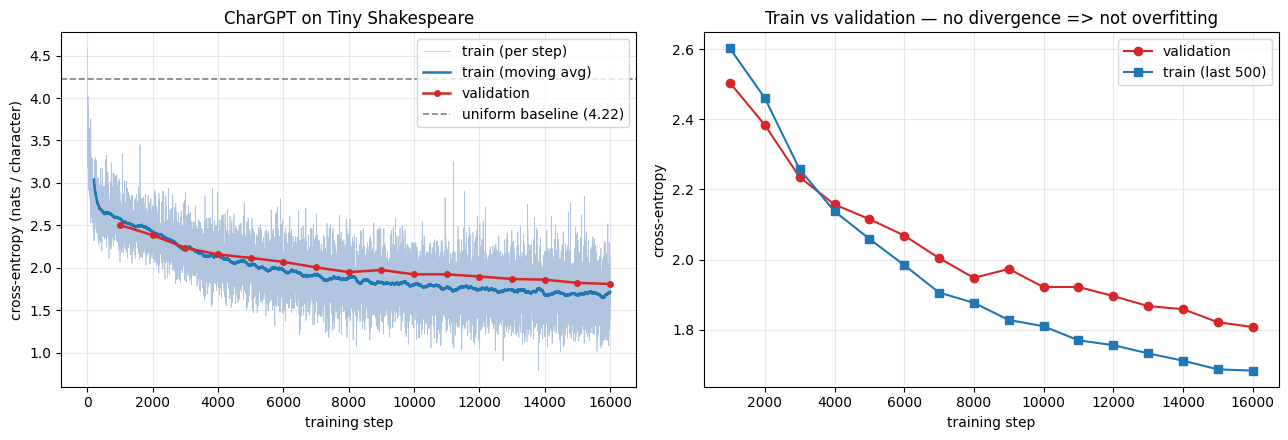

train/val gap at the end: 0.124 nats (a large positive gap would mean memorization)


In [17]:
%matplotlib inline
import matplotlib.pyplot as plt


def moving_average(values: list[float], window: int = 200) -> np.ndarray:
    """Simple box-filter smoothing, for readability of a noisy per-step trace."""
    if len(values) < window:
        return np.array(values)
    kernel = np.ones(window) / window
    return np.convolve(np.array(values), kernel, mode="valid")


figure, (loss_axis, zoom_axis) = plt.subplots(1, 2, figsize=(13, 4.5))

# --- left: full training run ---
loss_axis.plot(train_losses, color="lightsteelblue", linewidth=0.5, label="train (per step)")
smoothed = moving_average(train_losses, 200)
loss_axis.plot(np.arange(len(smoothed)) + 200, smoothed, color="tab:blue", linewidth=1.8,
               label="train (moving avg)")
loss_axis.plot(evaluated_steps, validation_losses, "o-", color="tab:red", linewidth=1.8,
               markersize=4, label="validation")
loss_axis.axhline(shakespeare_baseline_loss, color="gray", linestyle="--", linewidth=1.2,
                  label=f"uniform baseline ({shakespeare_baseline_loss:.2f})")
loss_axis.set_xlabel("training step")
loss_axis.set_ylabel("cross-entropy (nats / character)")
loss_axis.set_title("CharGPT on Tiny Shakespeare")
loss_axis.legend()
loss_axis.grid(alpha=0.3)

# --- right: train vs validation only, to check for overfitting ---
zoom_axis.plot(evaluated_steps, validation_losses, "o-", color="tab:red", label="validation")
train_at_eval = [float(np.mean(train_losses[max(0, s - 500):s])) for s in evaluated_steps]
zoom_axis.plot(evaluated_steps, train_at_eval, "s-", color="tab:blue", label="train (last 500)")
zoom_axis.set_xlabel("training step")
zoom_axis.set_ylabel("cross-entropy")
zoom_axis.set_title("Train vs validation — no divergence => not overfitting")
zoom_axis.legend()
zoom_axis.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"train/val gap at the end: "
      f"{abs(train_at_eval[-1] - validation_losses[-1]):.3f} nats "
      f"(a large positive gap would mean memorization)")

## Evaluation — perplexity and samples

In [18]:
validation_perplexity: float = float(np.exp(final_validation_loss))
baseline_perplexity: float = float(np.exp(shakespeare_baseline_loss))

print(f"validation loss       : {final_validation_loss:.3f} nats/char")
print(f"validation perplexity : {validation_perplexity:.2f}")
print(f"uniform baseline      : {baseline_perplexity:.2f}")
print(f"improvement           : {baseline_perplexity / validation_perplexity:.1f}x better "
      f"than random guessing")


for temperature in [0.5, 0.8, 1.0]:
    print(f"\n{'=' * 70}\nsample at temperature {temperature}\n{'=' * 70}")
    print(shakespeare_model.generate(
        shakespeare_tokenizer, max_new_tokens=400, temperature=temperature, seed=1
    ))

print(f"\n{'=' * 70}\ncontinuing the prompt 'ROMEO:'\n{'=' * 70}")
print(shakespeare_model.generate(
    shakespeare_tokenizer, max_new_tokens=300, temperature=0.8, seed=7, prompt="ROMEO:"
))

validation loss       : 1.808 nats/char
validation perplexity : 6.10
uniform baseline      : 68.00
improvement           : 11.1x better than random guessing

sample at temperature 0.5
 way much the fool for would with thee bounds
That weep with and like being to thee was marriage
The prover with the pose the change thee,
Marcious should the with some wordong to thee humbled thee clencess in durper
And when not for would be the come pon a conted bening one
With and this call with in their being with her
Marcians for brother pose it not their to come thee curse.
I see comes more 

sample at temperature 0.8
comment of perfool forcution will,
We may past this comessin I till to my naturion.
A that chame spitison pay farmed more, he,
And swore with earrest with the vition it you,
For which I you thee ling of sun, that thing pated
Than compustes be sing the look ach that but beare
With and thou calsence chappery thee,
How a day in a beholdly to recome foot;
And never with the his withers me 

## Hyperparameter study

        step    train      val   elapsed    left
  2000/2000     2.598    2.384       41s      0s
        step    train      val   elapsed    left
  2000/2000     2.825    2.685       48s      0s
        step    train      val   elapsed    left
  2000/2000     2.738    2.495       41s      0s
        step    train      val   elapsed    left
  2000/2000     2.649    2.459       18s      0s
        step    train      val   elapsed    left
  2000/2000     2.581    2.340       13s      0s
        step    train      val   elapsed    left
  2000/2000     2.645    2.455       30s      0s
configuration            d_model  heads  blocks       lr    params  val loss
----------------------------------------------------------------------------
shallower (1 block)          128      4       1    5e-04   224,196     2.340
baseline                     128      4       3    5e-04   620,740     2.384
single head                  128      1       3    5e-04   620,740     2.455
narrower (d_model 64)      

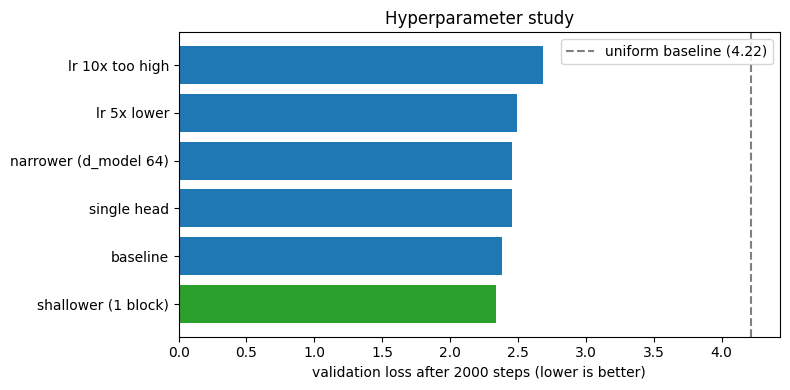

In [19]:
def run_configuration(
    label: str,
    d_model: int,
    number_of_heads: int,
    number_of_blocks: int,
    lr: float,
    steps: int = 2000,
    block_size: int = 64,
) -> dict:
    """Train a fresh model briefly and report its held-out loss."""
    model = CharGPT(
        shakespeare_tokenizer.vocab_size,
        d_model=d_model,
        number_of_heads=number_of_heads,
        number_of_blocks=number_of_blocks,
        max_sequence_length=block_size,
    )
    _train_losses, _steps_evaluated, validation_history = train_with_validation(
        model, train_token_ids, validation_token_ids,
        steps=steps, block_size=block_size, lr=lr, evaluate_every=steps,
    )
    return {
        "label": label,
        "d_model": d_model,
        "heads": number_of_heads,
        "blocks": number_of_blocks,
        "lr": lr,
        "parameters": model.parameter_count(),
        "validation_loss": validation_history[-1],
    }


configurations = [
    # (label,                d_model, heads, blocks, lr)
    ("baseline",                 128,     4,      3,  5e-4),
    ("lr 10x too high",          128,     4,      3,  5e-3),
    ("lr 5x lower",              128,     4,      3,  1e-4),
    ("narrower (d_model 64)",     64,     4,      3,  5e-4),
    ("shallower (1 block)",      128,     4,      1,  5e-4),
    ("single head",              128,     1,      3,  5e-4),
]

results = [run_configuration(*configuration) for configuration in configurations]

print(f"{'configuration':<24}{'d_model':>8}{'heads':>7}{'blocks':>8}"
      f"{'lr':>9}{'params':>10}{'val loss':>10}")
print("-" * 76)
for result in sorted(results, key=lambda row: row["validation_loss"]):
    print(f"{result['label']:<24}{result['d_model']:>8}{result['heads']:>7}"
          f"{result['blocks']:>8}{result['lr']:>9.0e}{result['parameters']:>10,}"
          f"{result['validation_loss']:>10.3f}")

best_result = min(results, key=lambda row: row["validation_loss"])
print(f"\nbest after 2000 steps: {best_result['label']} "
      f"(val loss {best_result['validation_loss']:.3f})")

# what the numbers say
figure, axis = plt.subplots(figsize=(8, 4))
sorted_results = sorted(results, key=lambda row: row["validation_loss"])
axis.barh([row["label"] for row in sorted_results],
          [row["validation_loss"] for row in sorted_results],
          color=["tab:green" if row is best_result else "tab:blue" for row in sorted_results])
axis.axvline(shakespeare_baseline_loss, color="gray", linestyle="--",
             label=f"uniform baseline ({shakespeare_baseline_loss:.2f})")
axis.set_xlabel("validation loss after 2000 steps (lower is better)")
axis.set_title("Hyperparameter study")
axis.legend()
plt.tight_layout()
plt.show()

In [20]:
print(shakespeare_model.generate(shakespeare_tokenizer, max_new_tokens=400,
                                 temperature=0.8, prompt="JULIET:"))

JULIET:
GaUst thou wast: come, peyouse come word,
But sent the mon made slow suive sworn purpounts;
Withoum erred waul this budgeth friend, om thy one
To thing show the not founds butdrows brooks of ray,
To in good our bundrither but come pressent with to
me you wather,
For may boutinge's must? Go, in crown and pruke.

LARENCE:
And sing partion I the dofteming to done a may
So the good were not, to do me
